# Finding Groups: The K-Means Clustering Algorithm

### What is Clustering?

Clustering is the task of automatically grouping a set of objects (our data points) in such a way that objects in the same group (called a **cluster**) are more similar to each other than to those in other groups.

Think of it as the digital equivalent of someone dumping a mixed bag of Lego bricks on the floor, and your job is to sort them into separate piles based on their color or shape, *without* anyone telling you what the categories are.

### K-Means: The Core Idea

The K-Means algorithm is the most popular way to do this. Its goal is simple: to partition $N$ data points into $K$ distinct, non-overlapping clusters.

The "Means" part of the name refers to how it works: it finds the "center" of each cluster, known as a **centroid** (which is just the mean, or average, of all the points in that cluster). It then assigns each data point to the cluster with the nearest centroid.

### The K-Means Algorithm: A Step-by-Step Dance

This is the best part—the algorithm is a simple, iterative two-step "dance" that just keeps repeating until it settles on a perfect solution.

Here's the process:

1.  **Step 1: Choose $K$.** First, we have to decide *how many* clusters we want to find (e.g., $K=3$). This is the trickiest part, and we'll cover how to do this in a moment.

2.  **Step 2: Initialize Centroids.** The algorithm randomly plops $K$ centroids onto your data's graph. These are the "starting guesses" for the cluster centers.

3.  **Step 3: The Assignment Step.** The algorithm looks at *every single data point* and calculates its distance to each of the $K$ centroids. It assigns the data point to the cluster of the **nearest centroid**.

4.  **Step 4: The Update Step.** Now that all points are assigned to a cluster, the algorithm re-calculates the center of each cluster by taking the *mean* of all the points assigned to it. It then *moves* the cluster's centroid to this new mean.

5.  **Step 5: Repeat.** The dance continues! We go back to Step 3. Now that the centroids have moved, some points might be closer to a *different* cluster. So, all points are re-assigned. Then, in Step 4, the centroids are updated again.

This "Assign & Update" loop repeats until the centroids stop moving (or move very, very little). When the assignments no longer change, we say the algorithm has **converged**.

### The Big Question: How to Choose $K$?

The algorithm requires us to choose $K$ upfront. How do we know if we should look for 3 clusters, 4 clusters, or 5?

We use a technique called the **Elbow Method**.

1.  **Define Inertia:** We need a way to measure how good our clustering is. A good clustering has tightly-packed clusters. We can measure this with **Inertia** (also called Sum of Squared Errors). This is simply the sum of the squared distances of each point to its assigned centroid. A *lower* inertia means the clusters are *tighter*.

2.  **Run Many Models:** We run our K-Means algorithm multiple times, each time with a different $K$ (e.g., $K=1, 2, 3, ... , 10$). We record the `inertia_` for each $K$.

3.  **Plot the Results:** We create a line plot of $K$ (on the x-axis) versus Inertia (on the y-axis).

4.  **Find the "Elbow":** The plot will almost always look like an arm. As $K$ increases, inertia will always decrease (if $K$ equals the number of points, inertia is 0!). But we are looking for the "elbow"—the point where the inertia starts to decrease much more slowly. This point of "diminishing returns" is the best trade-off between the number of clusters and the tightness of each cluster.

### Pros and Cons of K-Means

K-Means is a BTech student's best friend, but you must know its strengths and weaknesses.

**Pros:**

* **Simple & Intuitive:** You can explain it to anyone.

* **Fast:** It's computationally efficient and scales well to very large datasets.

* **Wide Applicability:** It's the "go-to" first algorithm for any clustering task.

**Cons:**

* **Must Choose $K$:** The Elbow Method helps, but it's not always perfect.

* **Sensitive to Initialization:** The random starting position of the centroids can sometimes lead to a "bad" solution. (Pro-tip: `scikit-learn` solves this by running the algorithm multiple times with different random starts, using `n_init=10` by default).

* **Assumes Spherical Clusters:** K-Means assumes clusters are spherical and roughly the same size. It fails on complex, non-spherical shapes (like concentric circles or half-moons).

K-Means is the "Linear Regression" of clustering—a simple, powerful, and essential tool that forms the foundation for more complex techniques.

---
## K-Means in Practice (Python Examples)

Now, let's see these concepts in action.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs, make_moons, load_iris
from sklearn.preprocessing import StandardScaler

# Set up plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

### Example 1: The "Hello World" of K-Means

We'll create 4 distinct "blobs" of data and watch K-Means find them.

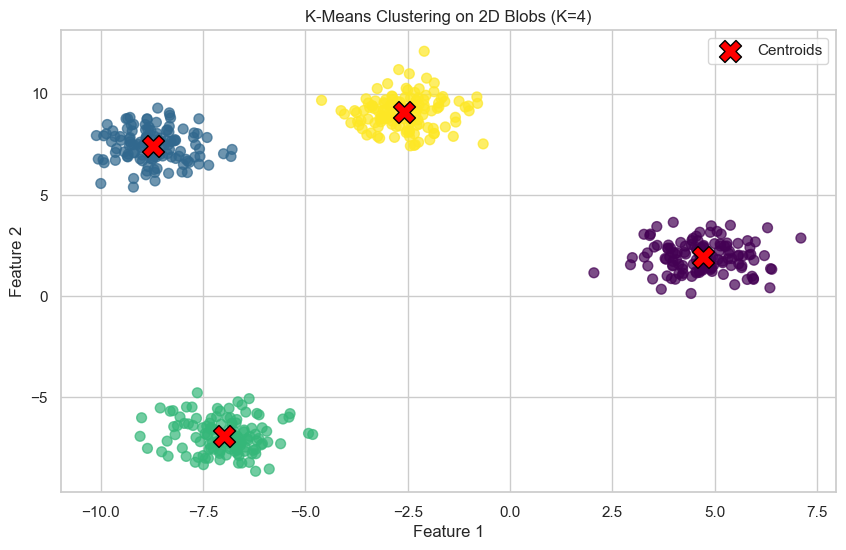

In [2]:
# We create 4 distinct "blobs" of data
X_blobs, y_blobs = make_blobs(
    n_samples=500,
    centers=4,
    cluster_std=0.8,
    random_state=42
)

# Initialize KMeans with K=4
# n_init=10 tells scikit-learn to run the algorithm 10 times
# with different random starts and pick the best one.
kmeans_blobs = KMeans(n_clusters=4, n_init=10, random_state=42)

# Fit the model and predict the clusters
y_pred_blobs = kmeans_blobs.fit_predict(X_blobs)

# Get the final cluster centers
centroids = kmeans_blobs.cluster_centers_

# Plot the results
plt.figure()
plt.scatter(
    X_blobs[:, 0],
    X_blobs[:, 1],
    c=y_pred_blobs,  # Color points by their *predicted* cluster
    cmap='viridis',
    s=50,
    alpha=0.7
)
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    c='red',
    s=250,
    marker='X',
    edgecolor='black',
    label='Centroids'
)
plt.title('K-Means Clustering on 2D Blobs (K=4)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

### Example 2: The Elbow Method in Practice

Now let's use the same data, but pretend we don't know that K=4. We'll use the Elbow Method to find the best K.

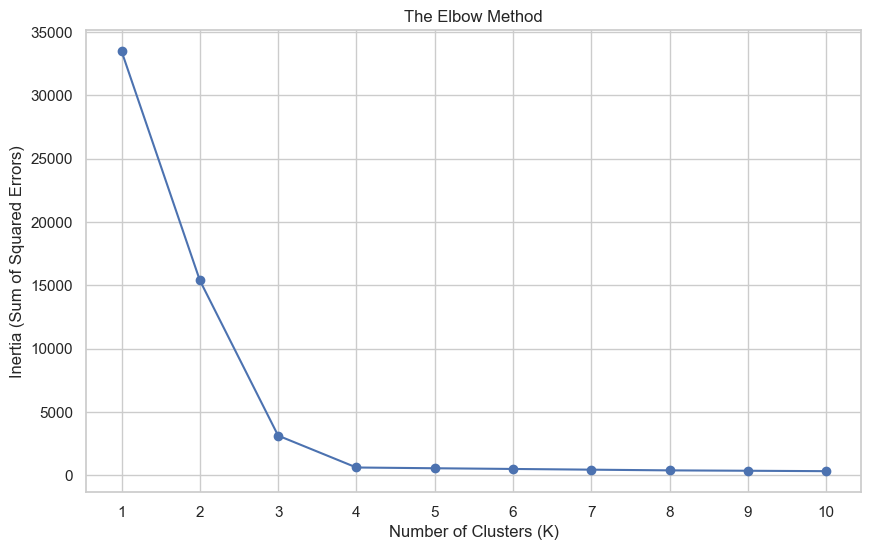

Elbow Method Plot: Notice the 'elbow' at K=4. This is the optimal number of clusters!


In [3]:
# We will use the same blob data from Example 1
inertia_values = []
k_range = range(1, 11)  # We will test K from 1 to 10

for k in k_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(X_blobs)
    inertia_values.append(kmeans.inertia_) # inertia_ stores the SSE

# Plot K vs. Inertia
plt.figure()
plt.plot(k_range, inertia_values, 'bo-')
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Sum of Squared Errors)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

print("Elbow Method Plot: Notice the 'elbow' at K=4. This is the optimal number of clusters!")

### Example 3: Applying K-Means to a Real Dataset (Iris)

Let's see if K-Means can *discover* the 3 species of Iris flowers without being told what they are.

In [4]:
# Load the dataset
iris = load_iris()
X_iris = iris.data
y_iris_true = iris.target # These are the *real* labels we will use for comparison

# Scale the data (K-Means is distance-based, so scaling is important)
scaler = StandardScaler()
X_iris_scaled = scaler.fit_transform(X_iris)

# We know from domain knowledge (or the elbow method) that K=3
kmeans_iris = KMeans(n_clusters=3, n_init=10, random_state=42)
y_iris_pred = kmeans_iris.fit_predict(X_iris_scaled)

# Create a DataFrame to compare the true labels vs. predicted labels
comparison_df = pd.DataFrame({
    'True Species': y_iris_true,
    'Predicted Cluster': y_iris_pred
})

# Use pd.crosstab (a confusion matrix) to see how well they line up
# Note: The cluster labels (0, 1, 2) might not match the species labels (0, 1, 2)
# e.g., Cluster 0 might be Species 1, Cluster 1 might be Species 2, etc.
crosstab = pd.crosstab(comparison_df['True Species'], comparison_df['Predicted Cluster'])

print("\n--- Iris Dataset Clustering Results ---")
print("Crosstab (True Labels vs. Predicted Clusters):")
print(crosstab)
print("\nWe can see the algorithm did a very good job of separating the species!")
print("It perfectly found all 50 of species 0.")
print("It confused a few of species 1 and 2, which are known to be very similar.")


--- Iris Dataset Clustering Results ---
Crosstab (True Labels vs. Predicted Clusters):
Predicted Cluster   0   1   2
True Species                 
0                   0  50   0
1                  39   0  11
2                  14   0  36

We can see the algorithm did a very good job of separating the species!
It perfectly found all 50 of species 0.
It confused a few of species 1 and 2, which are known to be very similar.


### Example 4: The *Limits* of K-Means (The Moons Dataset)

K-Means assumes clusters are spherical. What happens when they are not? This is a crucial limitation to understand.

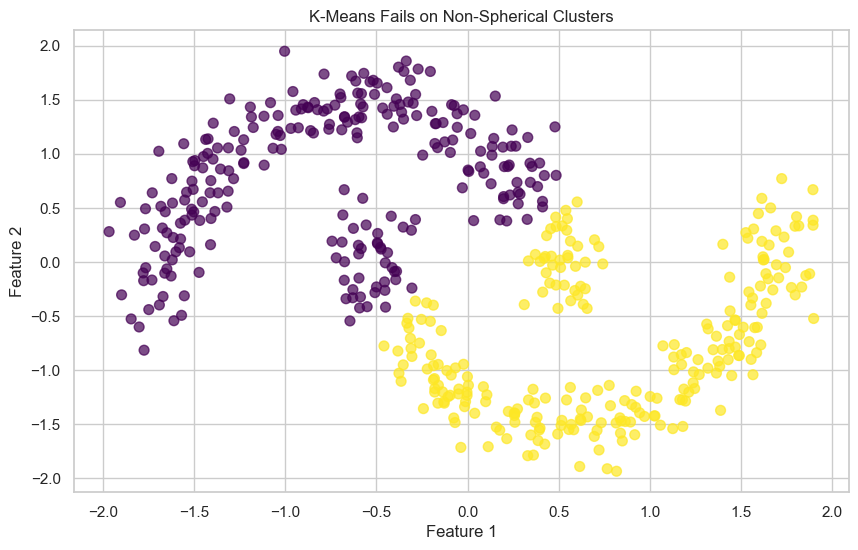


As you can see, K-Means fails on the moons dataset because it can only find linear boundaries.
It cuts the two moons in half, which is not the result we wanted.
This shows the importance of knowing your algorithm's assumptions!


: 

In [ ]:
# K-Means assumes clusters are spherical. What happens when they are not?
X_moons, y_moons = make_moons(n_samples=500, noise=0.1, random_state=42)

# Scale the data
X_moons_scaled = StandardScaler().fit_transform(X_moons)

# Fit K-Means with K=2
kmeans_moons = KMeans(n_clusters=2, n_init=10, random_state=42)
y_moons_pred = kmeans_moons.fit_predict(X_moons_scaled)

# Plot the results
plt.figure()
plt.scatter(
    X_moons_scaled[:, 0],
    X_moons_scaled[:, 1],
    c=y_moons_pred,
    cmap='viridis',
    s=50,
    alpha=0.7
)
plt.title('K-Means Fails on Non-Spherical Clusters')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

print("\nAs you can see, K-Means fails on the moons dataset because it can only find linear boundaries.")
print("It cuts the two moons in half, which is not the result we wanted.")
print("This shows the importance of knowing your algorithm's assumptions!")